In [1]:

!pip install transformers torch sentencepiece -q



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 89.8 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which 

In [2]:
!pip install pyaptamer==0.1.0a1


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 24.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 73.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.6/271.6 kB 13.2 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from pyaptamer.datasets import load_aptacom_x_y
from pyaptamer.datasets.dataclasses import MaskedDataset
import matplotlib.pyplot as plt
from difflib import SequenceMatcher
from torch.optim.lr_scheduler import CosineAnnealingLR
import pandas as pd
import torch.nn.functional as F
import math
from difflib import SequenceMatcher



### reference paper 
https://arxiv.org/abs/2502.21274 

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel, AutoModelForMaskedLM
from torch.utils.data import Dataset, DataLoader

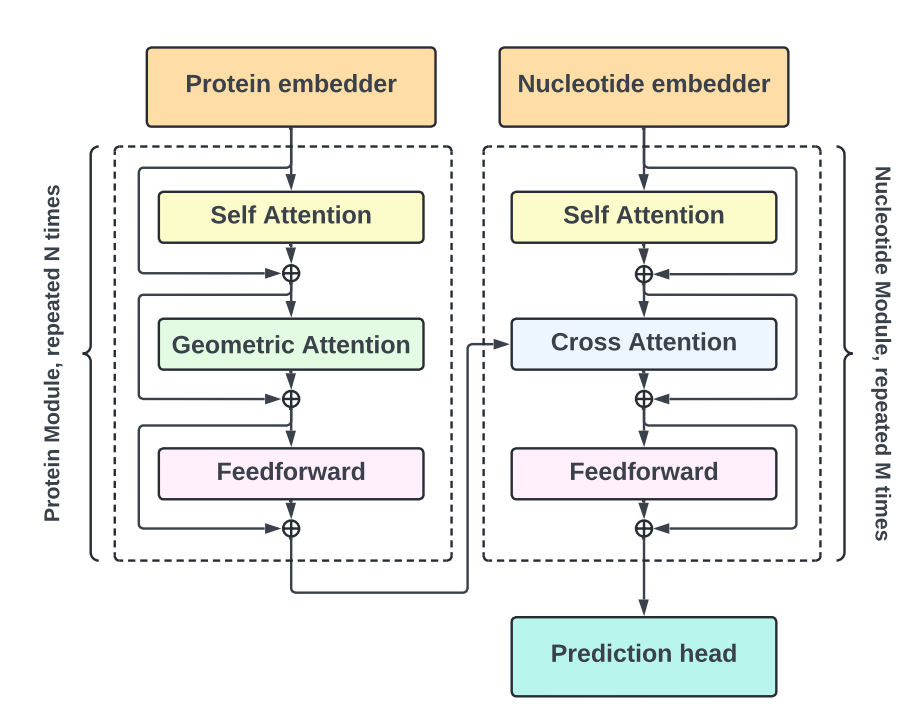

### The frozen encoders to be used to generate embeddings 

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
# protein encoder : ems2 : we keep it frozen
"""prot_tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t33_650M_UR50D")
prot_encoder   = AutoModel.from_pretrained("facebook/esm2_t33_650M_UR50D").to(device)
for p in prot_encoder.parameters():
    p.requires_grad = False
prot_encoder.eval()"""
 
# nucleotide encoder ,nucTransfor same frozen 
nuc_tokenizer = AutoTokenizer.from_pretrained(
    "InstaDeepAI/nucleotide-transformer-500m-human-ref"
)
nuc_encoder = AutoModelForMaskedLM.from_pretrained(
    "InstaDeepAI/nucleotide-transformer-500m-human-ref"
).to(device)
for p in nuc_encoder.parameters():
    p.requires_grad = False
nuc_encoder.eval()
 
NUC_DIM  = 1280   # nucTransfor hidden size   
MASK_TOKEN_ID = nuc_tokenizer.mask_token_id
print(f"MASK token id: {MASK_TOKEN_ID}")  #the id of the[MASK] token

config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

EsmForMaskedLM LOAD REPORT from: InstaDeepAI/nucleotide-transformer-500m-human-ref
Key                         | Status     |  | 
----------------------------+------------+--+-
esm.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

MASK token id: 2


In [6]:
print(nuc_tokenizer.vocab_size)  

4107


### the cross attention layer for the nuc module

In [7]:
class CrossAttentionLayer(nn.Module):
    def __init__(self,d_model= 128, n_heads = 4, dropout= 0.1):
        # the communication bridge between the two encoders via attentiopn
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, nuc_repr, prot_repr, prot_key_padding_mask=None):
 
        attn_out, _ = self.attn(
            query=nuc_repr,
            key=prot_repr,
            value=prot_repr,
            key_padding_mask=prot_key_padding_mask,  
        )
        return self.norm(nuc_repr + self.dropout(attn_out))

## the nucmodule
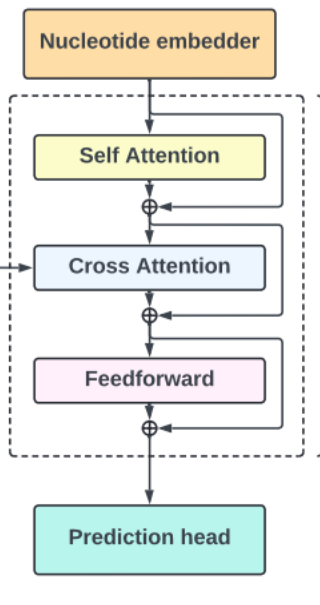

we have proj -- self att -- corss attention -- ffn

In [9]:
class NucleotideModule(nn.Module):
     def __init__(self, nuc_dim=1280, d_model=128, n_heads=4, n_layers=3, dropout=0.1,use_cross_att=True,vocab_size=4000):
         super().__init__()
         self.use_cross_att = use_cross_att
         self.head = nn.Linear(d_model, vocab_size)

         self.proj = nn.Sequential(
                    nn.Linear(nuc_dim, d_model),
                    nn.LayerNorm(d_model),)
        
                #the self attention bloc
         self.self_attn_blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads,
                dim_feedforward=d_model*4, dropout=dropout,
                batch_first=True, activation="gelu")
            for _ in range(n_layers)
        ])
         self.cross_attn_blocks = nn.ModuleList([
            CrossAttentionLayer(d_model, n_heads, dropout)
            for _ in range(n_layers)
        ])
         
     def forward(self, nuc, prot=None, nuc_padding_mask=None, prot_padding_mask=None):
        nuc = self.proj(nuc)
        for self_attn, cross_attn in zip(self.self_attn_blocks, self.cross_attn_blocks):
            nuc = self_attn(nuc, src_key_padding_mask=nuc_padding_mask)
            if self.use_cross_att and prot is not None:
                nuc = cross_attn(nuc, prot, prot_key_padding_mask=prot_padding_mask)
        return self.head(nuc)


## Data and dataset class

In [14]:
from pyaptamer.datasets import load_aptacom_x_y,load_li2014

X, y = load_aptacom_x_y(return_X_y=True) #types are df
#y is not binary it is affility scores 


AptaCom04.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/5556 [00:00<?, ? examples/s]

In [15]:
print(X.columns)
print(y.columns)

print(len(X))
#print(y["new_affinity"].unique())  

Index(['aptamer_sequence', 'target_sequence'], dtype='object')
Index(['new_affinity'], dtype='object')
709


In [16]:
x2,y2=load_li2014()
print(len(x2),len(y2))

2900 2900


In [17]:
print(y2.columns)
print(x2.columns)
print(y2["label"].unique())

Index(['label'], dtype='object')
Index(['aptamer', 'protein'], dtype='object')
['positive' 'negative']


### We fine tune the NT model

In [18]:
seqs_aptacom = X['aptamer_sequence'].dropna().tolist()
seqs_li      = x2['aptamer'].dropna().tolist()  
all_aptamer_seqs = list(set(seqs_aptacom + seqs_li))  # dedup
print(f"Total unique aptamers: {len(all_aptamer_seqs)}")
print(len(seqs_aptacom + seqs_li)) 

Total unique aptamers: 1363
3609


In [19]:
X_aptamer=pd.DataFrame(all_aptamer_seqs, columns=["aptamer_sequence"])
X_aptamer

,aptamer_sequence
0,CCACAGTACTACCGTATAACATGATGTCAA
1,TCTCGGACGCGTGTGGTCGGGTGGGAGTTGTGGGGGGGGGTGGGAG...
2,CAGAACGUAUACUAUUCUG
3,GGTTGGTCTGGTTGG
4,CACUGCAGUGUAUGCAAAGCUU
...,...
1358,GGGAGGACGATGCGGAGTTTCTTCTGAGGTCTGAACCTTTCGAAAG...
1359,CGUCCCGUAGGCCAAUUGCGUCCCACCUUAACGUCCGCC
1360,CGGACGAAATTCGTCCCTGTGTG
1361,GGTTGTGAAGATTGGGAGCGTCGTGGCTAC


In [20]:

#we tokznise using the NT tokenizer 
tokenized_nuc = nuc_tokenizer(
    all_aptamer_seqs,
    return_tensors='pt', padding=True, truncation=True, max_length=128
)
nuc_input_ids = tokenized_nuc['input_ids'] 

# MaskedDataset (token IDs --→ masked samples)
NUC_VOCAB_SIZE = nuc_tokenizer.vocab_size
MASK_TOKEN_IDX = nuc_tokenizer.mask_token_id

dataset = MaskedDataset(
    x=nuc_input_ids.numpy(),  
    y=nuc_input_ids.numpy(),
    max_len=nuc_input_ids.shape[1],
    mask_idx=MASK_TOKEN_IDX,
    masked_rate=0.19,
    is_rna=False
)

In [ ]:
# the dataset we will use
train_size = int(0.9 * len(dataset))
val_size   = len(dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False)
num_epochs = 10


In [21]:

#model and optimizer
model = NucleotideModule(
    nuc_dim=1280, d_model=128, n_heads=4, n_layers=3,
    dropout=0.1, use_cross_att=False, vocab_size=NUC_VOCAB_SIZE
).to(device)

nuc_encoder.train()
for p in nuc_encoder.parameters():
    p.requires_grad = True

optimizer = optim.Adam([
    {"params": nuc_encoder.parameters(), "lr": 1e-5},
    {"params": model.parameters(),       "lr": 1e-3},
])
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)


In [23]:

nuc_encoder.gradient_checkpointing_enable()

for epoch in range(num_epochs):
    model.train()
    nuc_encoder.train()
    total_loss = 0

    for x_masked, y_masked, x_orig, y_orig in train_loader:
        x_masked = x_masked.to(device)
        y_masked = y_masked.to(device)

        nuc_hidden = nuc_encoder(
            x_masked,
            output_hidden_states=True
        ).hidden_states[-1] 
        nuc_pad_mask = (x_masked == 0)  
        logits = model(nuc_hidden, nuc_padding_mask=nuc_pad_mask)
        loss = F.cross_entropy(
            logits.view(-1, NUC_VOCAB_SIZE),
            y_masked.view(-1),
            ignore_index=0
        )
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(model.parameters()) + list(nuc_encoder.parameters()), 1.0
        )
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/10 | Loss: 0.9094
Epoch 2/10 | Loss: 0.6872
Epoch 3/10 | Loss: 0.6450
Epoch 4/10 | Loss: 0.6194
Epoch 5/10 | Loss: 0.6432
Epoch 6/10 | Loss: 0.5844
Epoch 7/10 | Loss: 0.5921
Epoch 8/10 | Loss: 0.5703
Epoch 9/10 | Loss: 0.5583
Epoch 10/10 | Loss: 0.5390


In [24]:
# the aptamer encoder phase one
torch.save({
    'nuc_module': model.state_dict(),      #NT weights
    'nuc_encoder': nuc_encoder.state_dict() # NT encoder weights
}, 'phase1_aptamer_pretrain.pt')

print("Saved.")

Saved.


In [22]:
#how to laod it 
checkpoint = torch.load('/kaggle/input/models/majdoubnourelhouda/nt/pytorch/default/1/phase1_aptamer_pretrain.pt', map_location=device)

model.load_state_dict(checkpoint['nuc_module'])
nuc_encoder.load_state_dict(checkpoint['nuc_encoder'])

print("Loaded.")

Loaded.


In [24]:

def ids_to_str(token_ids, tokenizer, skip_special=True):
    """
    Helper function for the decoding from the tokens ids to the actual str
    """
    return tokenizer.decode(token_ids, skip_special_tokens=skip_special).replace(" ", "")


@torch.no_grad()
def evaluate(
    model,
    nuc_encoder,
    loader,
    tokenizer,
    device,
    vocab_size,
    pad_token_id=0,
    n_seq_samples=8,    
):
    model.eval()
    nuc_encoder.eval()

    total_loss    = 0.0
    total_correct = 0
    total_masked  = 0
    seq_ratios    = []
    logged        = 0

    for x_masked, y_masked, x_orig, y_orig in loader:
        x_masked = x_masked.to(device)   # [B, L]  – masked input
        y_masked = y_masked.to(device)   # [B, L]  – original token IDs (labels)

        nuc_hidden = nuc_encoder(
            x_masked,
            output_hidden_states=True,
        ).hidden_states[-1]               

        nuc_pad_mask = (x_masked == pad_token_id)  

        # NT module forward
        logits = model(nuc_hidden, nuc_padding_mask=nuc_pad_mask)   # [B, L, vocab_size]

        #  MLM loss
        loss = F.cross_entropy(
            logits.view(-1, vocab_size),
            y_masked.view(-1),
            ignore_index=pad_token_id,
        )
        total_loss += loss.item()

        # Masked-position accuracy
        is_masked  = (x_masked != y_masked) & (y_masked != pad_token_id)  
        preds      = logits.argmax(dim=-1)                                  
        correct    = (preds == y_masked) & is_masked
        total_correct += correct.sum().item()
        total_masked  += is_masked.sum().item()


    n_batches = len(loader)
    avg_loss  = total_loss / n_batches
    ppl       = math.exp(avg_loss)
    mask_acc  = total_correct / max(total_masked, 1)

    return {
        "loss":         avg_loss,
        "perplexity":   ppl,
        "mask_acc":     mask_acc,
       
    }

print("\n" + "="*60)
print("EVALUATION ON VALIDATION SET")
print("="*60)

metrics = evaluate(
    model       = model,
    nuc_encoder = nuc_encoder,
    loader      = val_loader,
    tokenizer   = nuc_tokenizer,
    device      = device,
    vocab_size  = NUC_VOCAB_SIZE,
    pad_token_id= 0,
    n_seq_samples=8,
)

print("\n── Summary ──────────────────────────────────────────────")
print(f"  Val Loss       : {metrics['loss']:.4f}")
print(f"  Perplexity     : {metrics['perplexity']:.2f}")
print(f"  Masked Acc     : {metrics['mask_acc']*100:.2f}%")
print("─────────────────────────────────────────────────────────\n")


EVALUATION ON VALIDATION SET

── Summary ──────────────────────────────────────────────
  Val Loss       : 0.5201
  Perplexity     : 1.68
  Masked Acc     : 89.06%
─────────────────────────────────────────────────────────

